## Load libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import tqdm
import os
import wandb



# Task 1
## Conditional Gan with 100 epochs

In [2]:
mb_size = 64
Z_dim = 1000
h_dim = 128
lr = 1e-3

# Load MNIST data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten the 28x28 image to 784
])

train_dataset = datasets.MNIST(root='../MNIST', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)

X_dim = 784  # 28 x 28

# Xavier Initialization
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# Generator
class Generator(nn.Module):
    def __init__(self, z_dim, h_dim, x_dim):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, x_dim)
        self.apply(xavier_init)

    def forward(self, z):
        h = F.relu(self.fc1(z))
        out = torch.sigmoid(self.fc2(h))
        return out

# Discriminator
class Discriminator(nn.Module):
    def __init__(self, x_dim, h_dim):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        out = torch.sigmoid(self.fc2(h))
        return out
# Training
def cGANTraining(G, D, loss_fn, train_loader):
    G.train()
    D.train()

    D_loss_real_total = 0
    D_loss_fake_total = 0
    G_loss_total = 0
    t = tqdm.tqdm(train_loader)

    for it, (X_real, labels) in enumerate(t):
        # Prepare real data
        X_real = X_real.float().to(device)

        # Sample noise and labels
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        ones_label = torch.ones(X_real.size(0), 1).to(device)
        zeros_label = torch.zeros(X_real.size(0), 1).to(device)

        # ================= Train Discriminator =================
        G_sample = G(z)
        D_real = D(X_real)
        D_fake = D(G_sample.detach())

        D_loss_real = loss_fn(D_real, ones_label)
        D_loss_fake = loss_fn(D_fake, zeros_label)
        D_loss = D_loss_real + D_loss_fake
        D_loss_real_total += D_loss_real.item()
        D_loss_fake_total += D_loss_fake.item()

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        # ================= Train Generator ====================
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        G_sample = G(z)
        D_fake = D(G_sample)

        G_loss = loss_fn(D_fake, ones_label)
        G_loss_total += G_loss.item()

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

    # ================= Logging =================
        D_loss_real_avg = D_loss_real_total / len(train_loader)
        D_loss_fake_avg = D_loss_fake_total / len(train_loader)
        D_loss_avg = D_loss_real_avg + D_loss_fake_avg
        G_loss_avg = G_loss_total / len(train_loader)

        wandb.log({
        "D_loss_real": D_loss_real_avg,
        "D_loss_fake": D_loss_fake_avg,
        "D_loss": D_loss_avg,
        "G_loss": G_loss_avg
       })

        return G, D, G_loss_avg, D_loss_avg

def save_sample(G, epoch, mb_size, Z_dim):
    out_dir = "out_vanila_GAN2"
    G.eval()
    with torch.no_grad():
        z = torch.randn(mb_size, Z_dim).to(device)
        samples = G(z).detach().cpu().numpy()[:16]

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis('off')
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect('equal')
        plt.imshow(sample.reshape(28, 28), cmap='Greys_r')

    if not os.path.exists(f'{out_dir}'):
        os.makedirs(f'{out_dir}')

    plt.savefig(f'{out_dir}/{str(epoch).zfill(3)}.png', bbox_inches='tight')
    plt.close(fig)

####################### Main #######################################
wandb_log = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Instantiate models
G = Generator(Z_dim, h_dim, X_dim).to(device)
D = Discriminator(X_dim, h_dim).to(device)

# Optimizers
G_solver = optim.Adam(G.parameters(), lr=lr)
D_solver = optim.Adam(D.parameters(), lr=lr)

# Loss function
def my_bce_loss(preds, targets):
    return F.binary_cross_entropy(preds, targets)

#loss_fn = nn.BCEWithLogitsLoss()
loss_fn = my_bce_loss

if wandb_log:
    wandb.init(project="conditional-gan-mnist")

    # Log hyperparameters
    wandb.config.update({
        "batch_size": mb_size,
        "Z_dim": Z_dim,
        "X_dim": X_dim,
        "h_dim": h_dim,
        "lr": lr,
    })

best_g_loss = float('inf')  # Initialize best generator loss
save_dir = 'checkpoints'
os.makedirs(save_dir, exist_ok=True)

#Train epochs
epochs = 100

for epoch in range(epochs):
    G, D, G_loss_avg, D_loss_avg= cGANTraining(G, D, loss_fn, train_loader)

    print(f'epoch{epoch}; D_loss: {D_loss_avg:.4f}; G_loss: {G_loss_avg:.4f}')

    if G_loss_avg < best_g_loss:
        best_g_loss = G_loss_avg
        torch.save(G.state_dict(), os.path.join(save_dir, 'G_best.pth'))
        torch.save(D.state_dict(), os.path.join(save_dir, 'D_best.pth'))
        print(f"Saved Best Models at epoch {epoch} | G_loss: {best_g_loss:.4f}")

    save_sample(G, epoch, mb_size, Z_dim)


# Inference
# G.load_state_dict(torch.load('checkpoints/G_best.pth'))
# G.eval()

# save_sample(G, "best", mb_size, Z_dim)




100%|██████████| 9.91M/9.91M [00:00<00:00, 11.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.17MB/s]
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sijiaderinto02new (sijiaderinto02new-ericsson) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

epoch97; D_loss: 0.0004; G_loss: 0.0034


  0%|          | 0/938 [00:00<?, ?it/s]


epoch98; D_loss: 0.0004; G_loss: 0.0035


  0%|          | 0/938 [00:00<?, ?it/s]


epoch99; D_loss: 0.0004; G_loss: 0.0036


# Task 2
## Logoistic GAN with 50, 10 and 5 epochs
- Discrimative NN
$$ \log(1 + \exp(-D(x_{real}))) + \log(1 + \exp(D(G{z})))$$
- Generative NN
$$\log(1 + \exp(-D(x_{real})))$$

In [3]:
## 50 epochs ##
######################## Settings ########################
mb_size = 64
Z_dim = 1000
h_dim = 128
lr = 1e-3
epochs = 50
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
wandb_log = True

###################### Load MNIST ########################
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten 28x28 to 784
])

train_dataset = datasets.MNIST(root='../MNIST', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)

X_dim = 784  # 28 x 28

#################### Xavier Initialization ####################
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

#################### Generator ####################
class Generator(nn.Module):
    def __init__(self, z_dim, h_dim, x_dim):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, x_dim)
        self.apply(xavier_init)

    def forward(self, z):
        h = F.relu(self.fc1(z))
        out = torch.sigmoid(self.fc2(h))
        return out

#################### Discriminator ####################
class Discriminator(nn.Module):
    def __init__(self, x_dim, h_dim):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        out = self.fc2(h)  #No Sigmoid! Output raw logits
        return out

#################### Logistic Loss Functions ####################
def D_logistic_loss(D_real_logits, D_fake_logits):
    real_loss = F.softplus(-D_real_logits).mean()  # log(1 + exp(-D(x_real)))
    fake_loss = F.softplus(D_fake_logits).mean()   # log(1 + exp(D(G(z))))
    return real_loss + fake_loss

def G_logistic_loss(D_fake_logits):
    return F.softplus(-D_fake_logits).mean()  # log(1 + exp(-D(G(z))))

#################### Training Function ####################
def cGANTraining(G, D, train_loader):
    G.train()
    D.train()

    D_loss_real_total = 0
    D_loss_fake_total = 0
    G_loss_total = 0
    t = tqdm.tqdm(train_loader)

    for it, (X_real, labels) in enumerate(t):
        X_real = X_real.float().to(device)

        # Sample noise
        z = torch.randn(X_real.size(0), Z_dim).to(device)

        # ============== Train Discriminator ==============
        G_sample = G(z)
        D_real_logits = D(X_real)
        D_fake_logits = D(G_sample.detach())

        D_loss = D_logistic_loss(D_real_logits, D_fake_logits)

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        # ============== Train Generator ==============
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        G_sample = G(z)
        D_fake_logits = D(G_sample)

        G_loss = G_logistic_loss(D_fake_logits)

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

        # ============== Logging ==============
        D_loss_real_total += F.softplus(-D_real_logits).mean().item()
        D_loss_fake_total += F.softplus(D_fake_logits).mean().item()
        G_loss_total += G_loss.item()


        D_loss_real_avg = D_loss_real_total / len(train_loader)
        D_loss_fake_avg = D_loss_fake_total / len(train_loader)
        D_loss_avg = D_loss_real_avg + D_loss_fake_avg
        G_loss_avg = G_loss_total / len(train_loader)

        if wandb_log:
          wandb.log({
            "D_loss_real": D_loss_real_avg,
            "D_loss_fake": D_loss_fake_avg,
            "D_loss": D_loss_avg,
            "G_loss": G_loss_avg
          })

        return G, D, G_loss_avg, D_loss_avg

#################### Save Sample Images ####################
def save_sample(G, epoch, mb_size, Z_dim):
    out_dir = "out_logistic_GAN"
    G.eval()
    with torch.no_grad():
        z = torch.randn(mb_size, Z_dim).to(device)
        samples = G(z).detach().cpu().numpy()[:16]

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis('off')
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect('equal')
        plt.imshow(sample.reshape(28, 28), cmap='Greys_r')

    if not os.path.exists(out_dir):
        os.makedirs(out_dir)

    plt.savefig(f'{out_dir}/{str(epoch).zfill(3)}.png', bbox_inches='tight')
    plt.close(fig)

#################### Main ####################
if wandb_log:
    wandb.init(project="logistic-loss-gan-mnist")
    wandb.config.update({
        "batch_size": mb_size,
        "Z_dim": Z_dim,
        "X_dim": X_dim,
        "h_dim": h_dim,
        "lr": lr,
    })

# Instantiate Models
G = Generator(Z_dim, h_dim, X_dim).to(device)
D = Discriminator(X_dim, h_dim).to(device)

# Optimizers
G_solver = optim.Adam(G.parameters(), lr=lr)
D_solver = optim.Adam(D.parameters(), lr=lr)

# Save Directory
save_dir = 'checkpoints_logistic'
os.makedirs(save_dir, exist_ok=True)
best_g_loss = float('inf')

# Training Loop
for epoch in range(epochs):
    G, D, G_loss_avg, D_loss_avg = cGANTraining(G, D, train_loader)

    print(f'epoch {epoch}; D_loss: {D_loss_avg:.4f}; G_loss: {G_loss_avg:.4f}')

    if G_loss_avg < best_g_loss:
        best_g_loss = G_loss_avg
        torch.save(G.state_dict(), os.path.join(save_dir, 'G_best.pth'))
        torch.save(D.state_dict(), os.path.join(save_dir, 'D_best.pth'))
        print(f"Saved Best Models at epoch {epoch} | G_loss: {best_g_loss:.4f}")

    save_sample(G, epoch, mb_size, Z_dim)


D_loss,█▄▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▂
D_loss_fake,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂
D_loss_real,██▅▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▂▁▁▂▁▁▂▂▂▂▂▂▂▃▃▄▄▄▄
G_loss,▁▄▄▃▃▅▆▆▆▆▆▆▆▇▇▇▇▇▇█▇▇▆▇▇▅▅▅▆▅▄▃▃▃▃▃▃▃▃▃
D_loss,0.00038
D_loss_fake,0.00013
D_loss_real,0.00025
G_loss,0.00356


  0%|          | 0/938 [00:00<?, ?it/s]


epoch 0; D_loss: 0.0009; G_loss: 0.0018
Saved Best Models at epoch 0 | G_loss: 0.0018


  0%|          | 0/938 [00:00<?, ?it/s]


epoch 1; D_loss: 0.0008; G_loss: 0.0025


...

epoch 47; D_loss: 0.0001; G_loss: 0.0050


  0%|          | 0/938 [00:00<?, ?it/s]


epoch 48; D_loss: 0.0001; G_loss: 0.0053


  0%|          | 0/938 [00:00<?, ?it/s]


epoch 49; D_loss: 0.0001; G_loss: 0.0056


In [ ]:
## 10 epochs ##
######################## Settings ########################
mb_size = 64
Z_dim = 1000
h_dim = 128
lr = 1e-3
epochs = 10
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
wandb_log = True

###################### Load MNIST ########################
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten 28x28 to 784
])

train_dataset = datasets.MNIST(root='../MNIST', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)

X_dim = 784  # 28 x 28

#################### Xavier Initialization ####################
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

#################### Generator ####################
class Generator(nn.Module):
    def __init__(self, z_dim, h_dim, x_dim):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, x_dim)
        self.apply(xavier_init)

    def forward(self, z):
        h = F.relu(self.fc1(z))
        out = torch.sigmoid(self.fc2(h))
        return out

#################### Discriminator ####################
class Discriminator(nn.Module):
    def __init__(self, x_dim, h_dim):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        out = self.fc2(h)  #No Sigmoid! Output raw logits
        return out

#################### Logistic Loss Functions ####################
def D_logistic_loss(D_real_logits, D_fake_logits):
    real_loss = F.softplus(-D_real_logits).mean()  # log(1 + exp(-D(x_real)))
    fake_loss = F.softplus(D_fake_logits).mean()   # log(1 + exp(D(G(z))))
    return real_loss + fake_loss

def G_logistic_loss(D_fake_logits):
    return F.softplus(-D_fake_logits).mean()  # log(1 + exp(-D(G(z))))

#################### Training Function ####################
def cGANTraining(G, D, train_loader):
    G.train()
    D.train()

    D_loss_real_total = 0
    D_loss_fake_total = 0
    G_loss_total = 0
    t = tqdm.tqdm(train_loader)

    for it, (X_real, labels) in enumerate(t):
        X_real = X_real.float().to(device)

        # Sample noise
        z = torch.randn(X_real.size(0), Z_dim).to(device)

        # ============== Train Discriminator ==============
        G_sample = G(z)
        D_real_logits = D(X_real)
        D_fake_logits = D(G_sample.detach())

        D_loss = D_logistic_loss(D_real_logits, D_fake_logits)

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        # ============== Train Generator ==============
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        G_sample = G(z)
        D_fake_logits = D(G_sample)

        G_loss = G_logistic_loss(D_fake_logits)

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

        # ============== Logging ==============
        D_loss_real_total += F.softplus(-D_real_logits).mean().item()
        D_loss_fake_total += F.softplus(D_fake_logits).mean().item()
        G_loss_total += G_loss.item()


        D_loss_real_avg = D_loss_real_total / len(train_loader)
        D_loss_fake_avg = D_loss_fake_total / len(train_loader)
        D_loss_avg = D_loss_real_avg + D_loss_fake_avg
        G_loss_avg = G_loss_total / len(train_loader)

        if wandb_log:
          wandb.log({
            "D_loss_real": D_loss_real_avg,
            "D_loss_fake": D_loss_fake_avg,
            "D_loss": D_loss_avg,
            "G_loss": G_loss_avg
          })

        return G, D, G_loss_avg, D_loss_avg

#################### Save Sample Images ####################
def save_sample(G, epoch, mb_size, Z_dim):
    out_dir = "out_logistic_GAN"
    G.eval()
    with torch.no_grad():
        z = torch.randn(mb_size, Z_dim).to(device)
        samples = G(z).detach().cpu().numpy()[:16]

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis('off')
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect('equal')
        plt.imshow(sample.reshape(28, 28), cmap='Greys_r')

    if not os.path.exists(out_dir):
        os.makedirs(out_dir)

    plt.savefig(f'{out_dir}/{str(epoch).zfill(3)}.png', bbox_inches='tight')
    plt.close(fig)

#################### Main ####################
if wandb_log:
    wandb.init(project="logistic-loss-gan-mnist")
    wandb.config.update({
        "batch_size": mb_size,
        "Z_dim": Z_dim,
        "X_dim": X_dim,
        "h_dim": h_dim,
        "lr": lr,
    })

# Instantiate Models
G = Generator(Z_dim, h_dim, X_dim).to(device)
D = Discriminator(X_dim, h_dim).to(device)

# Optimizers
G_solver = optim.Adam(G.parameters(), lr=lr)
D_solver = optim.Adam(D.parameters(), lr=lr)

# Save Directory
save_dir = 'checkpoints_logistic'
os.makedirs(save_dir, exist_ok=True)
best_g_loss = float('inf')

# Training Loop
for epoch in range(epochs):
    G, D, G_loss_avg, D_loss_avg = cGANTraining(G, D, train_loader)

    print(f'epoch {epoch}; D_loss: {D_loss_avg:.4f}; G_loss: {G_loss_avg:.4f}')

    if G_loss_avg < best_g_loss:
        best_g_loss = G_loss_avg
        torch.save(G.state_dict(), os.path.join(save_dir, 'G_best.pth'))
        torch.save(D.state_dict(), os.path.join(save_dir, 'D_best.pth'))
        print(f"Saved Best Models at epoch {epoch} | G_loss: {best_g_loss:.4f}")

    save_sample(G, epoch, mb_size, Z_dim)

D_loss,▅▆█▄▁
D_loss_fake,█▂▁▁▁
D_loss_real,▁▆█▄▁
G_loss,▁▅▇██
D_loss,0.00071
D_loss_fake,3e-05
D_loss_real,0.00069
G_loss,0.00394


  0%|          | 0/938 [00:00<?, ?it/s]


epoch 0; D_loss: 0.0010; G_loss: 0.0024
Saved Best Models at epoch 0 | G_loss: 0.0024


  0%|          | 0/938 [00:00<?, ?it/s]


epoch 1; D_loss: 0.0010; G_loss: 0.0034


...

epoch 7; D_loss: 0.0002; G_loss: 0.0037


  0%|          | 0/938 [00:00<?, ?it/s]


epoch 8; D_loss: 0.0002; G_loss: 0.0036


  0%|          | 0/938 [00:00<?, ?it/s]


epoch 9; D_loss: 0.0001; G_loss: 0.0038


In [ ]:
## 5 epochs ##
######################## Settings ########################
mb_size = 64
Z_dim = 1000
h_dim = 128
lr = 1e-3
epochs = 5
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
wandb_log = True

###################### Load MNIST ########################
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten 28x28 to 784
])

train_dataset = datasets.MNIST(root='../MNIST', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)

X_dim = 784  # 28 x 28

#################### Xavier Initialization ####################
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

#################### Generator ####################
class Generator(nn.Module):
    def __init__(self, z_dim, h_dim, x_dim):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, x_dim)
        self.apply(xavier_init)

    def forward(self, z):
        h = F.relu(self.fc1(z))
        out = torch.sigmoid(self.fc2(h))
        return out

#################### Discriminator ####################
class Discriminator(nn.Module):
    def __init__(self, x_dim, h_dim):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        out = self.fc2(h)  #No Sigmoid! Output raw logits
        return out

#################### Logistic Loss Functions ####################
def D_logistic_loss(D_real_logits, D_fake_logits):
    real_loss = F.softplus(-D_real_logits).mean()  # log(1 + exp(-D(x_real)))
    fake_loss = F.softplus(D_fake_logits).mean()   # log(1 + exp(D(G(z))))
    return real_loss + fake_loss

def G_logistic_loss(D_fake_logits):
    return F.softplus(-D_fake_logits).mean()  # log(1 + exp(-D(G(z))))

#################### Training Function ####################
def cGANTraining(G, D, train_loader):
    G.train()
    D.train()

    D_loss_real_total = 0
    D_loss_fake_total = 0
    G_loss_total = 0
    t = tqdm.tqdm(train_loader)

    for it, (X_real, labels) in enumerate(t):
        X_real = X_real.float().to(device)

        # Sample noise
        z = torch.randn(X_real.size(0), Z_dim).to(device)

        # ============== Train Discriminator ==============
        G_sample = G(z)
        D_real_logits = D(X_real)
        D_fake_logits = D(G_sample.detach())

        D_loss = D_logistic_loss(D_real_logits, D_fake_logits)

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        # ============== Train Generator ==============
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        G_sample = G(z)
        D_fake_logits = D(G_sample)

        G_loss = G_logistic_loss(D_fake_logits)

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

        # ============== Logging ==============
        D_loss_real_total += F.softplus(-D_real_logits).mean().item()
        D_loss_fake_total += F.softplus(D_fake_logits).mean().item()
        G_loss_total += G_loss.item()


        D_loss_real_avg = D_loss_real_total / len(train_loader)
        D_loss_fake_avg = D_loss_fake_total / len(train_loader)
        D_loss_avg = D_loss_real_avg + D_loss_fake_avg
        G_loss_avg = G_loss_total / len(train_loader)

        if wandb_log:
          wandb.log({
            "D_loss_real": D_loss_real_avg,
            "D_loss_fake": D_loss_fake_avg,
            "D_loss": D_loss_avg,
            "G_loss": G_loss_avg
          })

        return G, D, G_loss_avg, D_loss_avg

#################### Save Sample Images ####################
def save_sample(G, epoch, mb_size, Z_dim):
    out_dir = "out_logistic_GAN"
    G.eval()
    with torch.no_grad():
        z = torch.randn(mb_size, Z_dim).to(device)
        samples = G(z).detach().cpu().numpy()[:16]

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis('off')
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect('equal')
        plt.imshow(sample.reshape(28, 28), cmap='Greys_r')

    if not os.path.exists(out_dir):
        os.makedirs(out_dir)

    plt.savefig(f'{out_dir}/{str(epoch).zfill(3)}.png', bbox_inches='tight')
    plt.close(fig)

#################### Main ####################
if wandb_log:
    wandb.init(project="logistic-loss-gan-mnist")
    wandb.config.update({
        "batch_size": mb_size,
        "Z_dim": Z_dim,
        "X_dim": X_dim,
        "h_dim": h_dim,
        "lr": lr,
    })

# Instantiate Models
G = Generator(Z_dim, h_dim, X_dim).to(device)
D = Discriminator(X_dim, h_dim).to(device)

# Optimizers
G_solver = optim.Adam(G.parameters(), lr=lr)
D_solver = optim.Adam(D.parameters(), lr=lr)

# Save Directory
save_dir = 'checkpoints_logistic'
os.makedirs(save_dir, exist_ok=True)
best_g_loss = float('inf')

# Training Loop
for epoch in range(epochs):
    G, D, G_loss_avg, D_loss_avg = cGANTraining(G, D, train_loader)

    print(f'epoch {epoch}; D_loss: {D_loss_avg:.4f}; G_loss: {G_loss_avg:.4f}')

    if G_loss_avg < best_g_loss:
        best_g_loss = G_loss_avg
        torch.save(G.state_dict(), os.path.join(save_dir, 'G_best.pth'))
        torch.save(D.state_dict(), os.path.join(save_dir, 'D_best.pth'))
        print(f"Saved Best Models at epoch {epoch} | G_loss: {best_g_loss:.4f}")

    save_sample(G, epoch, mb_size, Z_dim)

D_loss,██▇▆▄▃▂▂▂▁
D_loss_fake,█▂▁▁▁▁▂▂▂▂
D_loss_real,▇█▇▆▅▃▂▂▂▁
G_loss,▁▅▇██▇▇▇▆▇
D_loss,0.00012
D_loss_fake,4e-05
D_loss_real,8e-05
G_loss,0.00377


  0%|          | 0/938 [00:00<?, ?it/s]


epoch 0; D_loss: 0.0008; G_loss: 0.0024
Saved Best Models at epoch 0 | G_loss: 0.0024


  0%|          | 0/938 [00:00<?, ?it/s]


epoch 1; D_loss: 0.0009; G_loss: 0.0033


...

epoch 2; D_loss: 0.0008; G_loss: 0.0036


  0%|          | 0/938 [00:00<?, ?it/s]


epoch 3; D_loss: 0.0006; G_loss: 0.0037


  0%|          | 0/938 [00:00<?, ?it/s]


epoch 4; D_loss: 0.0005; G_loss: 0.0038


# Task 3
## Labelled Conditional GANs

D_loss,██▇▅▅▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
D_loss_fake,█▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
D_loss_real,▇█▇▅▄▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁
G_loss,▁▂▃▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▇▆▇▇▇▇▆▇▇▇▇▇█▇▇██▇▇▇▇█
D_loss,7e-05
D_loss_fake,1e-05
D_loss_real,5e-05
G_loss,0.00564


100%|██████████| 938/938 [00:17<00:00, 54.17it/s]


Epoch 0 | D_loss: 0.0624 | G_loss: 5.8648
Saved Best Models at epoch 0 | G_loss: 5.8648


100%|██████████| 938/938 [00:19<00:00, 49.01it/s]


Epoch 1 | D_loss: 0.0521 | G_loss: 5.4976
Saved Best Models at epoch 1 | G_loss: 5.4976


...

Epoch 97 | D_loss: 0.8377 | G_loss: 1.6860


100%|██████████| 938/938 [00:19<00:00, 49.04it/s]


Epoch 98 | D_loss: 0.8411 | G_loss: 1.7128


100%|██████████| 938/938 [00:19<00:00, 48.04it/s]


Epoch 99 | D_loss: 0.8353 | G_loss: 1.7215


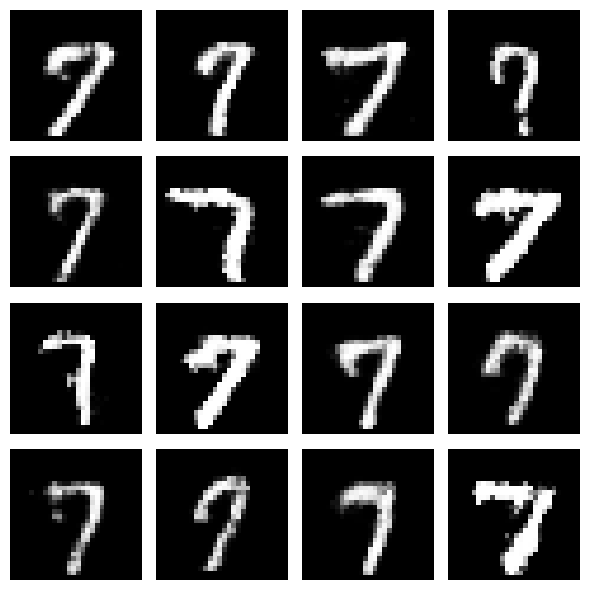

In [4]:

# Hyperparameters
mb_size = 64
Z_dim = 100
h_dim = 128
X_dim = 784  # 28x28
label_dim = 10  # for MNIST digits 0-9
lr = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load MNIST data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = datasets.MNIST(root='../MNIST', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)

# Xavier Initialization
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# One-hot encoding
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes=num_classes).float()

# Generator
class Generator(nn.Module):
    def __init__(self, z_dim, label_dim, h_dim, x_dim):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim + label_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, x_dim)
        self.apply(xavier_init)

    def forward(self, z, labels):
        inputs = torch.cat([z, labels], dim=1)
        h = F.relu(self.fc1(inputs))
        out = torch.sigmoid(self.fc2(h))
        return out

# Discriminator
class Discriminator(nn.Module):
    def __init__(self, x_dim, label_dim, h_dim):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim + label_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x, labels):
        inputs = torch.cat([x, labels], dim=1)
        h = F.relu(self.fc1(inputs))
        out = torch.sigmoid(self.fc2(h))
        return out

# Loss function
def my_bce_loss(preds, targets):
    return F.binary_cross_entropy(preds, targets)

# Instantiate models
G = Generator(Z_dim, label_dim, h_dim, X_dim).to(device)
D = Discriminator(X_dim, label_dim, h_dim).to(device)

# Optimizers
G_solver = optim.Adam(G.parameters(), lr=lr)
D_solver = optim.Adam(D.parameters(), lr=lr)

# Training function
def cGANTraining(G, D, loss_fn, train_loader):
    G.train()
    D.train()

    D_loss_real_total = 0
    D_loss_fake_total = 0
    G_loss_total = 0
    t = tqdm.tqdm(train_loader)

    for it, (X_real, labels) in enumerate(t):
        X_real = X_real.float().to(device)
        labels = labels.to(device)
        labels_onehot = one_hot(labels, num_classes=10).to(device)

        # Train Discriminator
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        sampled_labels = torch.randint(0, 10, (X_real.size(0),)).to(device)
        sampled_labels_onehot = one_hot(sampled_labels, num_classes=10).to(device)

        ones_label = torch.ones(X_real.size(0), 1).to(device)
        zeros_label = torch.zeros(X_real.size(0), 1).to(device)

        G_sample = G(z, sampled_labels_onehot)
        D_real = D(X_real, labels_onehot)
        D_fake = D(G_sample.detach(), sampled_labels_onehot)

        D_loss_real = loss_fn(D_real, ones_label)
        D_loss_fake = loss_fn(D_fake, zeros_label)
        D_loss = D_loss_real + D_loss_fake

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        # Train Generator
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        sampled_labels = torch.randint(0, 10, (X_real.size(0),)).to(device)
        sampled_labels_onehot = one_hot(sampled_labels, num_classes=10).to(device)

        G_sample = G(z, sampled_labels_onehot)
        D_fake = D(G_sample, sampled_labels_onehot)

        G_loss = loss_fn(D_fake, ones_label)

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

        # Track losses
        D_loss_real_total += D_loss_real.item()
        D_loss_fake_total += D_loss_fake.item()
        G_loss_total += G_loss.item()

    D_loss_real_avg = D_loss_real_total / len(train_loader)
    D_loss_fake_avg = D_loss_fake_total / len(train_loader)
    D_loss_avg = D_loss_real_avg + D_loss_fake_avg
    G_loss_avg = G_loss_total / len(train_loader)

    wandb.log({
        "D_loss_real": D_loss_real_avg,
        "D_loss_fake": D_loss_fake_avg,
        "D_loss": D_loss_avg,
        "G_loss": G_loss_avg
    })

    return G, D, G_loss_avg, D_loss_avg

# Sample and save generated images
def save_sample(G, epoch, mb_size, Z_dim, fixed_label=3):
    out_dir = "out_cGAN"
    G.eval()
    with torch.no_grad():
        z = torch.randn(mb_size, Z_dim).to(device)
        labels = torch.full((mb_size,), fixed_label, dtype=torch.long).to(device)
        labels_onehot = one_hot(labels, num_classes=10).to(device)
        samples = G(z, labels_onehot).detach().cpu().numpy()[:16]

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis('off')
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect('equal')
        plt.imshow(sample.reshape(28, 28), cmap='Greys_r')

    if not os.path.exists(f'{out_dir}'):
        os.makedirs(f'{out_dir}')

    plt.savefig(f'{out_dir}/{str(epoch).zfill(3)}.png', bbox_inches='tight')
    plt.close(fig)

# Main training loop
wandb_log = True

if wandb_log:
    wandb.init(project="conditional-gan-mnist")
    wandb.config.update({
        "batch_size": mb_size,
        "Z_dim": Z_dim,
        "X_dim": X_dim,
        "h_dim": h_dim,
        "lr": lr,
    })

save_dir = 'checkpoints'
os.makedirs(save_dir, exist_ok=True)

epochs = 100
best_g_loss = float('inf')

for epoch in range(epochs):
    G, D, G_loss_avg, D_loss_avg = cGANTraining(G, D, my_bce_loss, train_loader)

    print(f'Epoch {epoch} | D_loss: {D_loss_avg:.4f} | G_loss: {G_loss_avg:.4f}')

    if G_loss_avg < best_g_loss:
        best_g_loss = G_loss_avg
        torch.save(G.state_dict(), os.path.join(save_dir, 'G_best.pth'))
        torch.save(D.state_dict(), os.path.join(save_dir, 'D_best.pth'))
        print(f"Saved Best Models at epoch {epoch} | G_loss: {best_g_loss:.4f}")

    save_sample(G, epoch, mb_size, Z_dim, fixed_label=3)  # you can change fixed_label if you want to generate different digits


## Plot functions

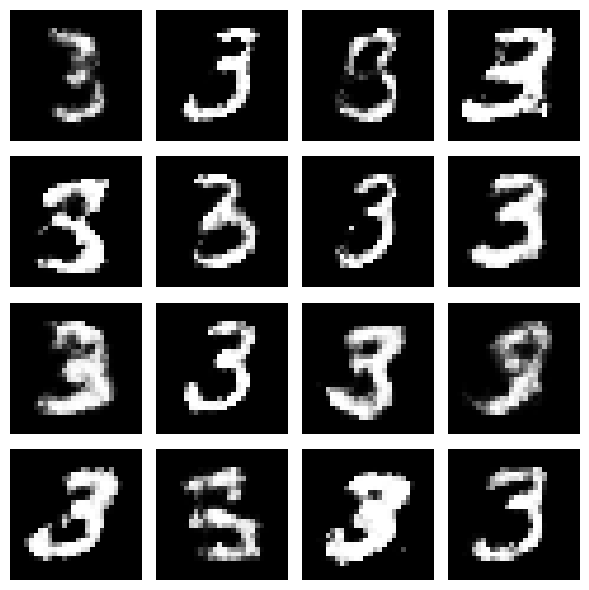

In [7]:
def generate_digit_samples(G, digit, n_samples=16):
    G.eval()
    z = torch.randn(n_samples, Z_dim).to(device)
    labels = torch.full((n_samples,), digit, dtype=torch.long).to(device)
    labels_onehot = F.one_hot(labels, num_classes=10).float()

    with torch.no_grad():
        samples = G(z, labels_onehot).cpu()

    return samples

# Plotting function
def plot_samples(samples, nrow=4, ncol=4):
    fig, axes = plt.subplots(nrow, ncol, figsize=(6,6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i].reshape(28, 28), cmap="gray")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

digit_to_generate = 3  # You can pick any number 0-9
samples = generate_digit_samples(G, digit_to_generate)
plot_samples(samples)

## Plot functions for all labels

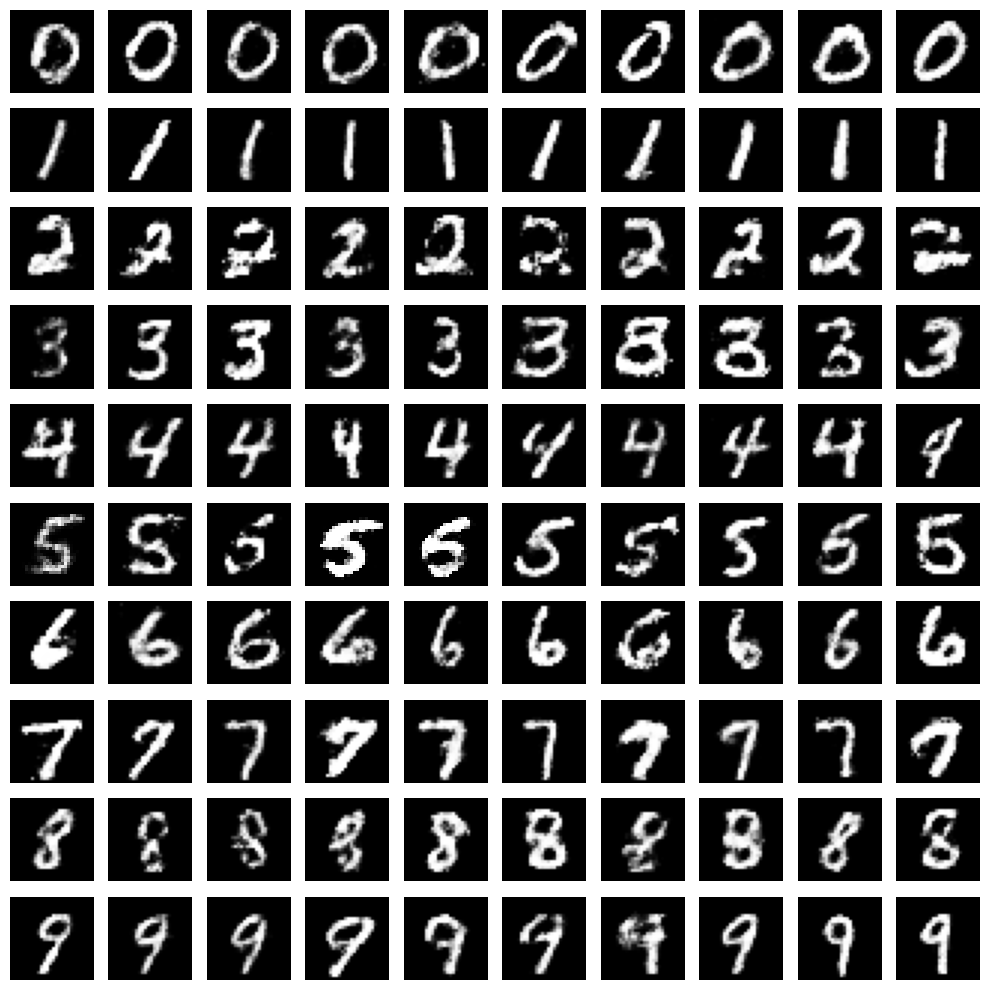

In [5]:
# Function to generate samples for a specific digit
def generate_digit_samples(G, digit, n_samples=10):
    G.eval()
    z = torch.randn(n_samples, Z_dim).to(device)
    labels = torch.full((n_samples,), digit, dtype=torch.long).to(device)
    labels_onehot = F.one_hot(labels, num_classes=10).float()

    with torch.no_grad():
        samples = G(z, labels_onehot).cpu()

    return samples


# Plotting all digits 0-9
def plot_all_digits(G, n_samples_per_digit=10):
    fig, axes = plt.subplots(10, n_samples_per_digit, figsize=(n_samples_per_digit, 10))

    for digit in range(10):
        samples = generate_digit_samples(G, digit, n_samples=n_samples_per_digit)
        for i in range(n_samples_per_digit):
            ax = axes[digit, i]
            ax.imshow(samples[i].reshape(28, 28), cmap="gray")
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage:
plot_all_digits(G)

# Task 4

- Train a CNN on MNIST
- Create adversarial examples by adding random noise to digits 4
- Final image is classified as 9 by the CNN model


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Hyperparameters
batch_size = 64
learning_rate = 0.001
epochs = 5

# Data
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# CNN Model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.max_pool2d(torch.relu(self.conv2(x)), 2)
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))

        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(epochs):
    model.train()
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} complete")

# Save the trained model
torch.save(model.state_dict(), 'mnist_cnn.pth')


###############################################



Epoch 1 complete
Epoch 2 complete
Epoch 3 complete
Epoch 4 complete
Epoch 5 complete


Original label: 4
Adversarial predicted label: 9


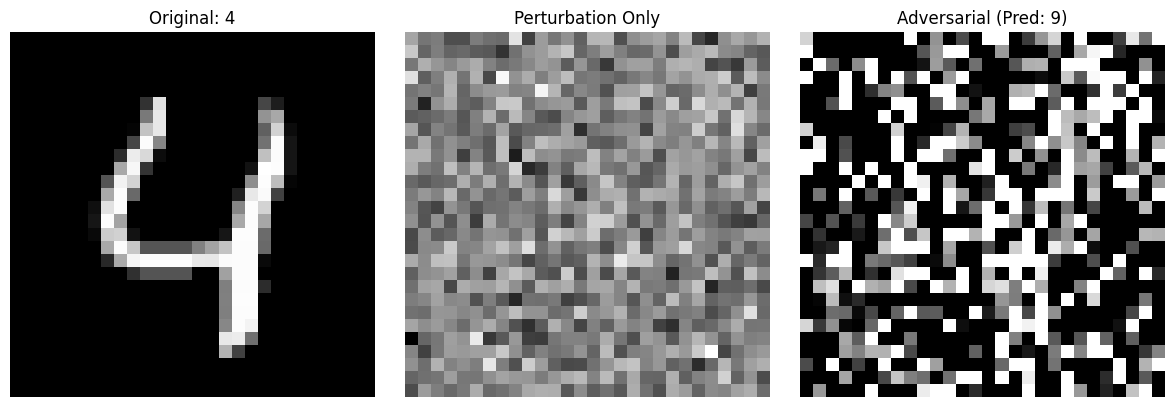

In [13]:

# Assume model, device, criterion, and test_loader are already loaded
# Load trained model
model = SimpleCNN().to(device)
model.load_state_dict(torch.load('mnist_cnn.pth'))
model.eval()

# 1. Pick a real image of "4"
for data, target in test_loader:
    mask = target == 4
    if mask.sum() > 0:
        img = data[mask][0].unsqueeze(0).to(device)
        true_label = target[mask][0]
        break

# 2. Set up
target_label = 9  # Force model to think it's a "9"
steps = 100
lr = 0.01

# 3. Initialize a small random perturbation
perturbation = torch.randn_like(img, requires_grad=True, device=device)
optimizer = optim.Adam([perturbation], lr=lr)

# 4. Train perturbation to fool the model
for step in range(steps):
    optimizer.zero_grad()

    adv_img = img + perturbation
    adv_img = torch.clamp(adv_img, 0, 1)  # Keep pixel values valid

    output = model(adv_img)
    loss = criterion(output, torch.tensor([target_label]).to(device))  # Want it classified as 9
    loss.backward()
    optimizer.step()

# 5. Final predictions
output = model(adv_img)
pred_label_adv = output.argmax(dim=1).item()

print(f"Original label: {true_label.item()}")
print(f"Adversarial predicted label: {pred_label_adv}")

# 6. Plot: Original, Perturbation, Adversarial
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(img.squeeze().detach().cpu(), cmap='gray')
axs[0].set_title(f"Original: {true_label.item()}")
axs[0].axis('off')

axs[1].imshow(perturbation.squeeze().detach().cpu(), cmap='gray')
axs[1].set_title("Perturbation Only")
axs[1].axis('off')

axs[2].imshow(adv_img.squeeze().detach().cpu(), cmap='gray')
axs[2].set_title(f"Adversarial (Pred: {pred_label_adv})")
axs[2].axis('off')

plt.tight_layout()
plt.show()



# Task 5

In [14]:


######################### Hyperparameters #########################
mb_size = 64
Z_dim = 1000  # Unused in Diffusion (noise directly from normal distribution)
h_dim = 128
lr = 1e-3
epochs = 50
timesteps = 1000  # Number of diffusion steps
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
wandb_log = True

######################### Load MNIST #########################
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten 28x28 to 784
])

train_dataset = datasets.MNIST(root='../MNIST', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)

X_dim = 784  # 28 x 28

######################### Forward Diffusion Process #########################
def get_beta_schedule(timesteps, start=1e-4, end=0.02):
    return torch.linspace(start, end, timesteps)

def forward_diffusion_sample(x_0, t, device="cuda"):
    noise = torch.randn_like(x_0).to(device)
    sqrt_alpha_cumprod = torch.sqrt(alpha_cumprod[t]).view(-1, 1)
    sqrt_one_minus_alpha_cumprod = torch.sqrt(1 - alpha_cumprod[t]).view(-1, 1)
    x_t = sqrt_alpha_cumprod * x_0 + sqrt_one_minus_alpha_cumprod * noise
    return x_t, noise

######################### Denoising Model (Simple FCNet) #########################
class SimpleDenoiseModel(nn.Module):
    def __init__(self, x_dim, h_dim):
        super(SimpleDenoiseModel, self).__init__()
        self.fc1 = nn.Linear(x_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, h_dim)
        self.fc3 = nn.Linear(h_dim, x_dim)
        self.apply(self.xavier_init)

    def xavier_init(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

######################### Diffusion Training Function #########################
def train_diffusion(model, train_loader, optimizer, epochs, timesteps):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x_0, _ in tqdm.tqdm(train_loader):
            x_0 = x_0.to(device)
            batch_size = x_0.shape[0]

            t = torch.randint(0, timesteps, (batch_size,), device=device).long()
            x_t, noise = forward_diffusion_sample(x_0, t, device)

            noise_pred = model(x_t)

            loss = F.mse_loss(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.6f}")

        if wandb_log:
            wandb.log({"loss": avg_loss})

######################### Sampling Function #########################
@torch.no_grad()
def sample_images(model, n_samples, timesteps):
    model.eval()
    x = torch.randn(n_samples, X_dim).to(device)

    for t in reversed(range(timesteps)):
        z = torch.randn_like(x) if t > 0 else 0
        beta_t = betas[t]
        sqrt_one_minus_alpha_cumprod_t = torch.sqrt(1 - alpha_cumprod[t])
        sqrt_recip_alpha_t = torch.sqrt(1.0 / alphas[t])

        model_mean = sqrt_recip_alpha_t * (x - beta_t / sqrt_one_minus_alpha_cumprod_t * model(x))

        if t > 0:
            noise = torch.randn_like(x)
            x = model_mean + torch.sqrt(beta_t) * noise
        else:
            x = model_mean

    return x

######################### Save Generated Images #########################
def save_samples(samples, epoch, out_dir='diffusion_samples'):
    samples = samples.view(-1, 28, 28).cpu().numpy()
    if not os.path.exists(out_dir):
        os.makedirs(out_dir)

    fig, axs = plt.subplots(4, 4, figsize=(4,4))
    cnt = 0
    for i in range(4):
        for j in range(4):
            axs[i,j].imshow(samples[cnt], cmap='gray')
            axs[i,j].axis('off')
            cnt += 1
    plt.savefig(f"{out_dir}/sample_epoch_{epoch}.png")
    plt.close()

######################### Initialize #########################
# Beta Schedule
betas = get_beta_schedule(timesteps).to(device)
alphas = 1.0 - betas
alpha_cumprod = torch.cumprod(alphas, dim=0)

# Model
model = SimpleDenoiseModel(x_dim=X_dim, h_dim=h_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

if wandb_log:
    wandb.init(project="simple-stable-diffusion-mnist")
    wandb.config.update({
        "batch_size": mb_size,
        "Z_dim": Z_dim,
        "X_dim": X_dim,
        "h_dim": h_dim,
        "lr": lr,
        "timesteps": timesteps,hat
    })

######################### Train Model #########################
train_diffusion(model, train_loader, optimizer, epochs, timesteps)

######################### Generate Samples #########################
samples = sample_images(model, n_samples=16, timesteps=timesteps)
save_samples(samples, epoch="final")


D_loss,▁▁▂▅▆▇████████████████████████████████▇▇
D_loss_fake,▁▂▂▄▅▇███████████▇▇▇▇▇▇▇███▇█▇▇▇▇▇▇▇▇▇▇▇
D_loss_real,▁▁▂▃▄▇▇█████████████████████████████████
G_loss,█▅▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
D_loss,0.83527
D_loss_fake,0.38092
D_loss_real,0.45434
G_loss,1.72148


100%|██████████| 938/938 [00:14<00:00, 66.89it/s]


Epoch [1/50] | Loss: 0.946123


100%|██████████| 938/938 [00:13<00:00, 67.74it/s]


Epoch [2/50] | Loss: 0.904622


...

Epoch [48/50] | Loss: 0.893687


100%|██████████| 938/938 [00:15<00:00, 60.79it/s]


Epoch [49/50] | Loss: 0.893855


100%|██████████| 938/938 [00:15<00:00, 59.27it/s]


Epoch [50/50] | Loss: 0.893153


- GAN Generates images by passing random noise through a generator network to produce data, using a discriminator to guide learning through adversarial loss.

- Diffusion: Involves progressively adding noise to images (forward diffusion) and then reversing the process (reverse diffusion) using a denoising network.
- Diffusion model's training and sampling processes are more computationally intensive compared to a typical GAN but can potentially generate higher-quality and more diverse images